In [3]:
from tensorflow.keras.datasets import mnist

(train_x,train_y),(test_x,test_y)=mnist.load_data()


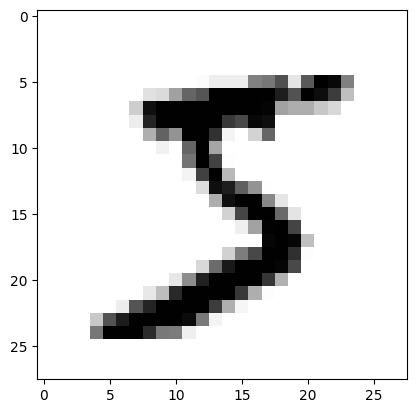

In [4]:
import numpy as np
import matplotlib.pyplot as plt

image=train_x[0]
plt.imshow(image,cmap=plt.cm.binary)
plt.show()


In [5]:
c_name=['zero','one','two','three','four','five','six','seven','eight','night']
len(c_name)

10

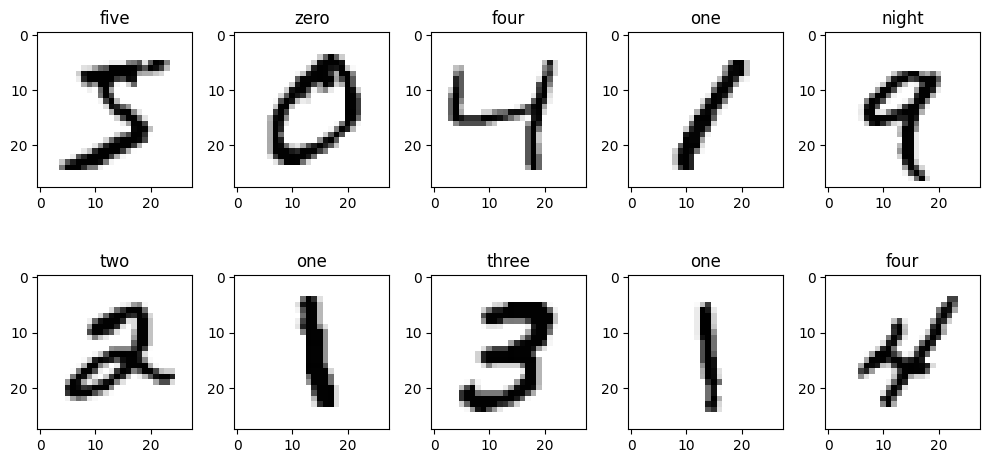

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.title(f'{c_name[train_y[i]]}')
    plt.imshow(train_x[i],cmap=plt.cm.binary)
plt.tight_layout()    
plt.show()    

In [7]:
train_x=train_x/255.0
test_x=test_x/255.0


In [8]:
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import Sequential

model=Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax')
        
    ]
)

model.summary()

C:\Users\mitba\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
op=SGD(learning_rate=0.05)

# model.compile(optimizer=op,loss=tf.keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])
model.compile(optimizer=op,loss=tf.keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])
model.fit(train_x,train_y,epochs=10,validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8897 - loss: 0.4032 - val_accuracy: 0.9319 - val_loss: 0.2396
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9395 - loss: 0.2158 - val_accuracy: 0.9492 - val_loss: 0.1809
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9534 - loss: 0.1649 - val_accuracy: 0.9586 - val_loss: 0.1505
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9619 - loss: 0.1348 - val_accuracy: 0.9638 - val_loss: 0.1323
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9681 - loss: 0.1145 - val_accuracy: 0.9671 - val_loss: 0.1180
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9725 - loss: 0.0985 - val_accuracy: 0.9669 - val_loss: 0.1138
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9763 - loss: 0.0870 - val_accuracy: 0.9693 - val_loss: 0.1066
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9791 - loss: 0.0769 - 

In [13]:
model.evaluate(test_x,test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9722 - loss: 0.0853


[0.08528293669223785, 0.9721999764442444]

In [15]:
pre=model.predict(test_x)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [16]:
lab_pre=np.argmax(pre[0])
lab_pre

np.int64(7)

In [17]:
test_y[0]

np.uint8(7)

In [18]:
pred=model.predict(np.expand_dims(image,axis=0))
c_name[np.argmax(pred)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


'five'

In [27]:
# =============================================================================================================================
from tensorflow.keras.layers import Conv2D,Flatten
model2=Sequential(
    [
      Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
      Flatten(input_shape=(28,28)),
      Dense(128,activation='relu'),
      Dense(10,activation='softmax'), 
    ]
)


In [38]:
from tensorflow.keras.optimizers  import  SGD
import tensorflow as tf
op1=SGD(learning_rate=0.05)

model2.compile(optimizer=op1,loss=tf.keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])

model2.fit(train_x,train_y,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9196 - loss: 0.2688 - val_accuracy: 0.9502 - val_loss: 0.1671
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9651 - loss: 0.1163 - val_accuracy: 0.9721 - val_loss: 0.0948
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9751 - loss: 0.0816 - val_accuracy: 0.9736 - val_loss: 0.0871
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9811 - loss: 0.0609 - val_accuracy: 0.9729 - val_loss: 0.0930
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9847 - loss: 0.0474 - val_accuracy: 0.9768 - val_loss: 0.0810
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9894 - loss: 0.0356 - val_accuracy: 0.9794 - val_loss: 0.0693
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9783 - val_loss: 0.0735
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9932 -

In [39]:
model2.evaluate(test_x,test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9805 - loss: 0.0642


[0.0641699954867363, 0.9804999828338623]

In [40]:
p1=model2.predict(test_x)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [41]:
p1_p=np.argmax(p1[30])
print(p1_p,'p',test_y[30],'a')


3 p 3 a
